In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure environment
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 1. Ingestion
print("==> Loading raw dataset...")
df = pd.read_csv('credit_risk_dataset.csv')
print(f"Initial Shape: {df.shape}")

# 2. Quality Audit: Missing Values
print("\n==> Auditing Missing Values (%):")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# 3. Advanced Conditional Imputation
# Rather than lazy global medians, we impute based on highly correlated categorical clusters.
print("\n==> Executing Conditional Imputation Strategy...")

# Interest rates are heavily tied to assigned loan grades
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median')
)

# Employment length relies on the structural profile of the applicant's home ownership status
df['person_emp_length'] = df['person_emp_length'].fillna(
    df.groupby('person_home_ownership')['person_emp_length'].transform('median')
)

print(f"Remaining Missing Values: {df.isnull().sum().sum()}")

Matplotlib is building the font cache; this may take a moment.


==> Loading raw dataset...
Initial Shape: (32581, 12)

==> Auditing Missing Values (%):
loan_int_rate        9.563856
person_emp_length    2.747000
dtype: float64

==> Executing Conditional Imputation Strategy...
Remaining Missing Values: 0


In [2]:
# 1. Profile Biological/Operational Anomalies
impossible_age = df[df['person_age'] > 100]
impossible_emp = df[df['person_emp_length'] > 60]

print(f"==> Anomalies Detected: {len(impossible_age)} records with Age > 100.")
print(f"==> Anomalies Detected: {len(impossible_emp)} records with Emp Length > 60.")

# 2. Clean Anomalies
df = df[(df['person_age'] <= 100) & (df['person_emp_length'] <= 60)].copy()

# 3. Winsorization of Heavily Skewed Financials
# Capping income at the 1st and 99th percentiles prevents millionaire outliers from skewing gradients
lower_bound = df['person_income'].quantile(0.01)
upper_bound = df['person_income'].quantile(0.99)

df['person_income'] = df['person_income'].clip(lower=lower_bound, upper=upper_bound)

print(f"==> Post-Cleaning Shape: {df.shape}")

==> Anomalies Detected: 5 records with Age > 100.
==> Anomalies Detected: 2 records with Emp Length > 60.
==> Post-Cleaning Shape: (32574, 12)


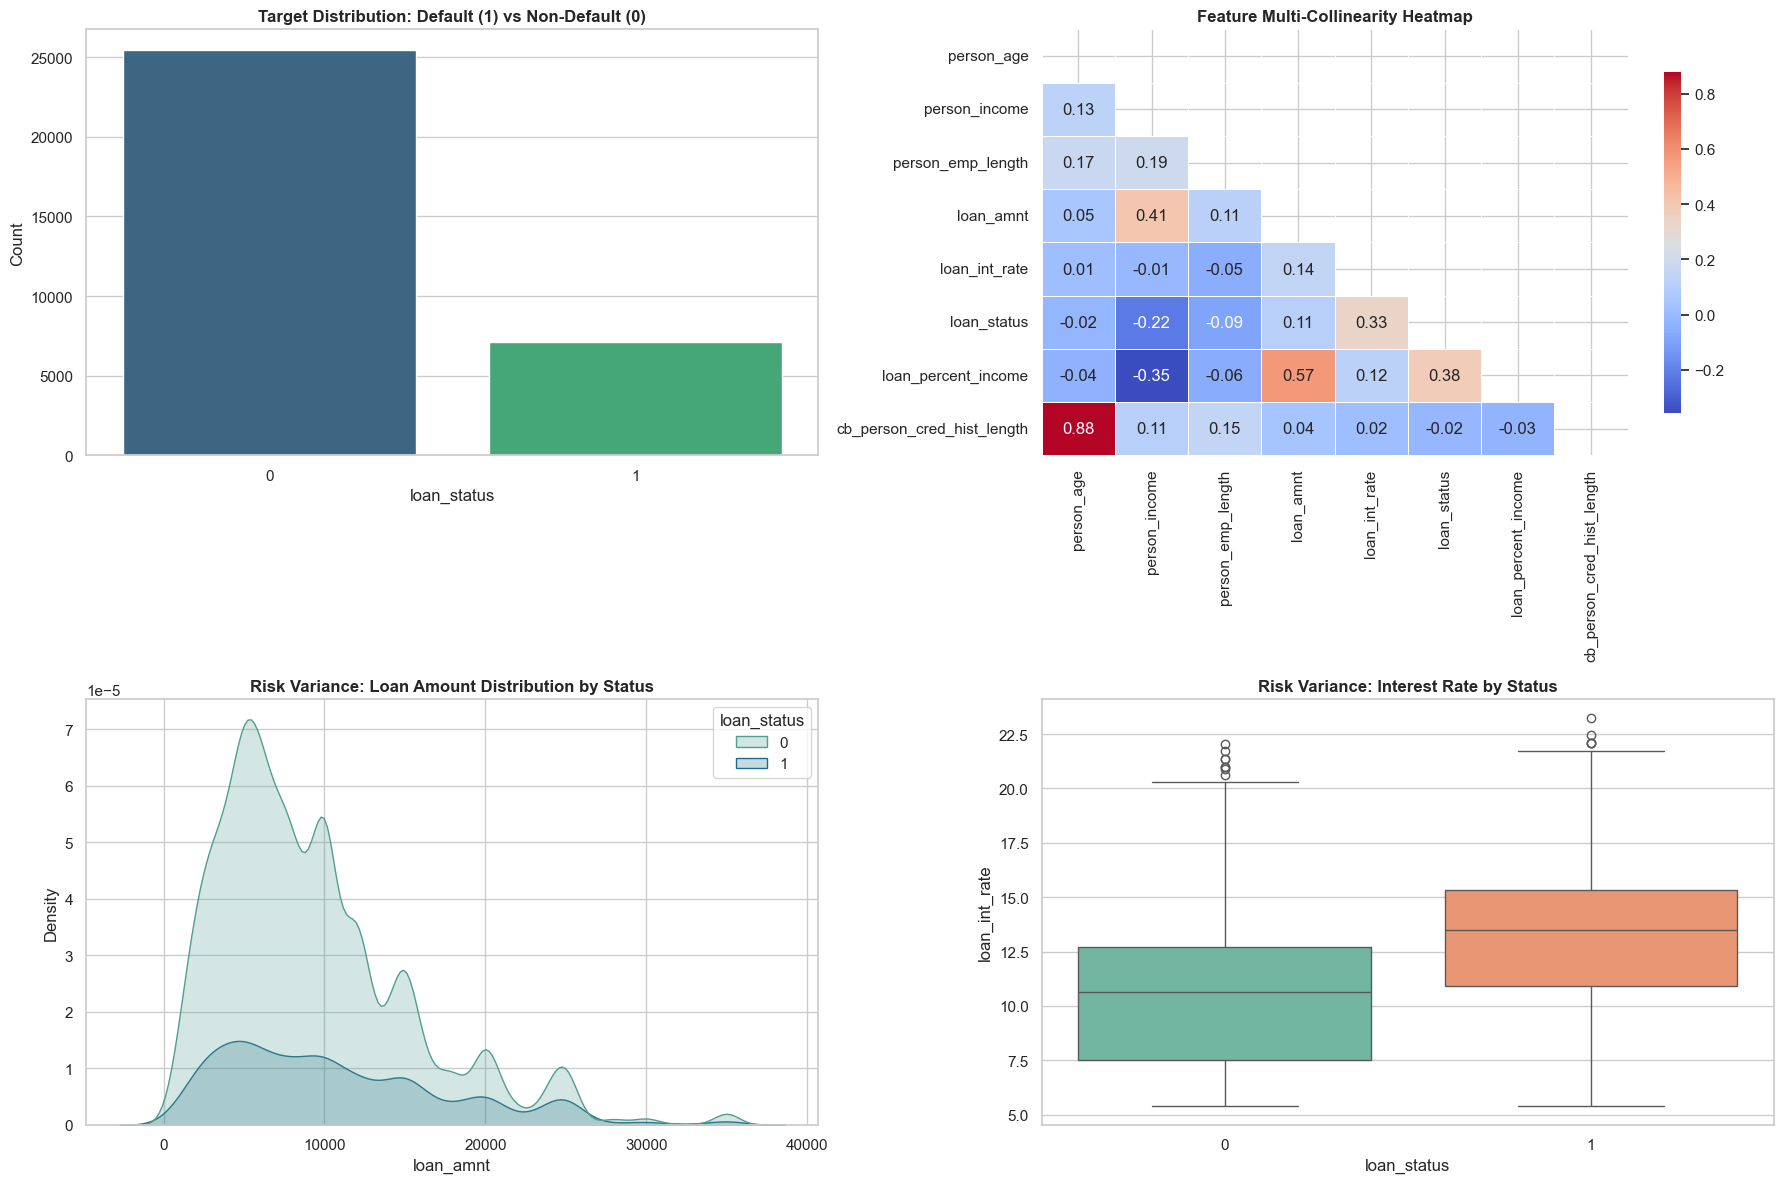

In [3]:
# Configure professional visualization theme
sns.set_theme(style="whitegrid", palette="muted")
fig = plt.figure(figsize=(18, 12))

# 1. Target Distribution & Class Imbalance
ax1 = plt.subplot(2, 2, 1)
sns.countplot(data=df, x='loan_status', ax=ax1, palette='viridis')
ax1.set_title('Target Distribution: Default (1) vs Non-Default (0)', weight='bold')
ax1.set_ylabel('Count')

# 2. Multi-Collinearity Grid (Numerical Variables Only)
ax2 = plt.subplot(2, 2, 2)
numerical_df = df.select_dtypes(include=[np.number])
corr = numerical_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, ax=ax2, cbar_kws={"shrink": .8})
ax2.set_title('Feature Multi-Collinearity Heatmap', weight='bold')

# 3. Risk-Segmented Distributions (Loan Amount)
ax3 = plt.subplot(2, 2, 3)
sns.kdeplot(data=df, x='loan_amnt', hue='loan_status', fill=True, palette='crest', ax=ax3)
ax3.set_title('Risk Variance: Loan Amount Distribution by Status', weight='bold')

# 4. Risk-Segmented Distributions (Interest Rate)
ax4 = plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='loan_status', y='loan_int_rate', palette='Set2', ax=ax4)
ax4.set_title('Risk Variance: Interest Rate by Status', weight='bold')

plt.tight_layout()
plt.show()

In [4]:
print("==> Initiating Feature Engineering Pipeline...")

# 1. Mathematical Transformations
# Log transformations squash long tails in massive financial metrics
df['person_income_log'] = np.log1p(df['person_income'])
df['loan_amnt_log'] = np.log1p(df['loan_amnt'])

# 2. Derive Institutional Risk Features
# Capacity Metric: Monthly Debt Load estimate
df['monthly_income'] = df['person_income'] / 12
df['est_monthly_debt_capacity'] = df['monthly_income'] * df['loan_percent_income']

# Credit Vulnerability Index: Composite tier of bureau default history & assigned grade
df['credit_vulnerability_index'] = df['loan_grade'].astype(str) + "_" + df['cb_person_default_on_file'].astype(str)

# 3. Production-Safe Categorical Encoding
# Using drop_first=True to avoid perfect collinearity (dummy variable trap)
categorical_features = [
    'person_home_ownership', 
    'loan_intent', 
    'loan_grade', 
    'cb_person_default_on_file',
    'credit_vulnerability_index'
]

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Ensure all OHE column names are clean strings (replaces spaces with underscores)
df_encoded.columns = [c.replace(' ', '_').lower() for c in df_encoded.columns]

print(f"==> Feature Engineering Complete. New Feature Space Size: {df_encoded.shape[1]} columns.")

==> Initiating Feature Engineering Pipeline...
==> Feature Engineering Complete. New Feature Space Size: 38 columns.


In [5]:
print("=====================================================")
print("             FINAL FEATURE MATRIX SUMMARY            ")
print("=====================================================")
print(f"Matrix Dimensions : {df_encoded.shape}")
print(f"Total Null Values : {df_encoded.isnull().sum().sum()}")
print("Target Variable   : 'loan_status' (Binary)")
print("=====================================================\n")

# Display evaluation-ready dataset footprint
display(df_encoded.head())

# (Optional for Production Pipeline Integration)
# df_encoded.to_csv('artifacts/data_transformation/full_engineered_features.csv', index=False)

             FINAL FEATURE MATRIX SUMMARY            
Matrix Dimensions : (32574, 38)
Total Null Values : 0
Target Variable   : 'loan_status' (Binary)



,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_income_log,loan_amnt_log,monthly_income,est_monthly_debt_capacity,person_home_ownership_other,person_home_ownership_own,person_home_ownership_rent,loan_intent_education,loan_intent_homeimprovement,loan_intent_medical,loan_intent_personal,loan_intent_venture,loan_grade_b,loan_grade_c,loan_grade_d,loan_grade_e,loan_grade_f,loan_grade_g,cb_person_default_on_file_y,credit_vulnerability_index_b_n,credit_vulnerability_index_c_n,credit_vulnerability_index_c_y,credit_vulnerability_index_d_n,credit_vulnerability_index_d_y,credit_vulnerability_index_e_n,credit_vulnerability_index_e_y,credit_vulnerability_index_f_n,credit_vulnerability_index_f_y,credit_vulnerability_index_g_n,credit_vulnerability_index_g_y
1,21,14400,5.0,1000,11.14,0,0.10,2,9.575053,6.908755,1200.000000,120.000000,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,25,14400,1.0,5500,12.87,1,0.57,3,9.575053,8.612685,1200.000000,684.000000,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,11.089821,10.463132,5458.333333,2892.916667,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,10.904138,10.463132,4533.333333,2493.333333,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
5,21,14400,2.0,2500,7.14,1,0.25,2,9.575053,7.824446,1200.000000,300.000000,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
